In [26]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [27]:
df= pd.read_csv("squads.csv",index_col=[0])

In [28]:
df

,team_name,player,nationality,role,designation
team_no,,,,,
1,Mumbai Indians,Hardik Pandya,Indian,All Rounder,Captain
1,Mumbai Indians,Rohit Sharma,Indian,Batter,NaN
1,Mumbai Indians,Suryakumar Yadav,Indian,Batter,NaN
1,Mumbai Indians,Jasprit Bumrah,Indian,Bowler,NaN
1,Mumbai Indians,Ryan Rickelton,Overseas,Wicket Keeper,NaN
...,...,...,...,...,...
10,Lucknow Super Giants,Digvesh Rathi,Indian,Bowler,NaN
10,Lucknow Super Giants,Arjun Tendulkar,Indian,Bowler,NaN
10,Lucknow Super Giants,Mohsin Khan,Indian,Bowler,NaN


### Data  preprocessing

In [29]:
df.dtypes

team_name      str
player         str
nationality    str
role           str
designation    str
dtype: object

In [30]:
# Inforamtion about data set
df.info()


<class 'pandas.DataFrame'>
Index: 257 entries, 1 to 10
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   team_name    257 non-null    str  
 1   player       257 non-null    str  
 2   nationality  257 non-null    str  
 3   role         257 non-null    str  
 4   designation  10 non-null     str  
dtypes: str(5)
memory usage: 23.5 KB


In [31]:
# Describe data set 
df.describe()

,team_name,player,nationality,role,designation
count,257,257,257,257,10
unique,10,257,2,4,1
top,Kolkata Night Riders,Hardik Pandya,Indian,Bowler,Captain
freq,28,1,175,106,10


In [32]:
# first rows
df.head(50)

,team_name,player,nationality,role,designation
team_no,,,,,
1,Mumbai Indians,Hardik Pandya,Indian,All Rounder,Captain
1,Mumbai Indians,Rohit Sharma,Indian,Batter,NaN
1,Mumbai Indians,Suryakumar Yadav,Indian,Batter,NaN
1,Mumbai Indians,Jasprit Bumrah,Indian,Bowler,NaN
1,Mumbai Indians,Ryan Rickelton,Overseas,Wicket Keeper,NaN
1,Mumbai Indians,Sherfane Rutherford,Overseas,Batter,NaN
1,Mumbai Indians,Naman Dhir,Indian,All Rounder,NaN
1,Mumbai Indians,Will Jacks,Overseas,All Rounder,NaN
1,Mumbai Indians,Shardul Thakur,Indian,All Rounder,NaN


In [33]:
# last  rows
df.tail(50)

,team_name,player,nationality,role,designation
team_no,,,,,
9,Delhi Capitals,Axar Patel,Indian,All Rounder,Captain
9,Delhi Capitals,Prithvi Shaw,Indian,Batter,NaN
9,Delhi Capitals,Pathum Nissanka,Overseas,Batter,NaN
9,Delhi Capitals,David Miller,Overseas,Batter,NaN
9,Delhi Capitals,Karun Nair,Indian,Batter,NaN
9,Delhi Capitals,Sahil Parakh,Indian,Batter,NaN
9,Delhi Capitals,Nitish Rana,Indian,Batter,NaN
9,Delhi Capitals,Abhishek Porel,Indian,Wicket Keeper,NaN
9,Delhi Capitals,KL Rahul,Indian,Wicket Keeper,NaN


In [34]:
df["designation"].unique()

<ArrowStringArray>
['Captain', nan]
Length: 2, dtype: str

In [35]:
df.fillna({"designation":"player"},inplace=True)

,team_name,player,nationality,role,designation
team_no,,,,,
1,Mumbai Indians,Hardik Pandya,Indian,All Rounder,Captain
1,Mumbai Indians,Rohit Sharma,Indian,Batter,player
1,Mumbai Indians,Suryakumar Yadav,Indian,Batter,player
1,Mumbai Indians,Jasprit Bumrah,Indian,Bowler,player
1,Mumbai Indians,Ryan Rickelton,Overseas,Wicket Keeper,player
...,...,...,...,...,...
10,Lucknow Super Giants,Digvesh Rathi,Indian,Bowler,player
10,Lucknow Super Giants,Arjun Tendulkar,Indian,Bowler,player
10,Lucknow Super Giants,Mohsin Khan,Indian,Bowler,player


In [36]:
df.isnull().sum()

team_name      0
player         0
nationality    0
role           0
designation    0
dtype: int64

In [37]:
df[df.duplicated()]

,team_name,player,nationality,role,designation
team_no,,,,,


In [38]:
df.duplicated()

team_no
1     False
1     False
1     False
1     False
1     False
      ...  
10    False
10    False
10    False
10    False
10    False
Length: 257, dtype: bool

## EDA

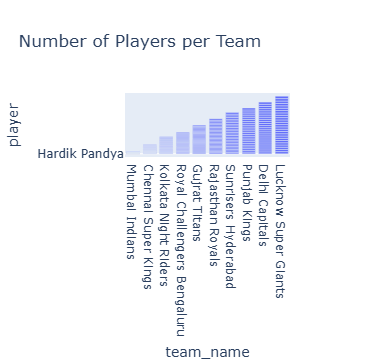

In [39]:
#  Bar: Team vs Players
fig = px.bar(df, x="team_name", y="player",
             title="Number of Players per Team")
fig.show()


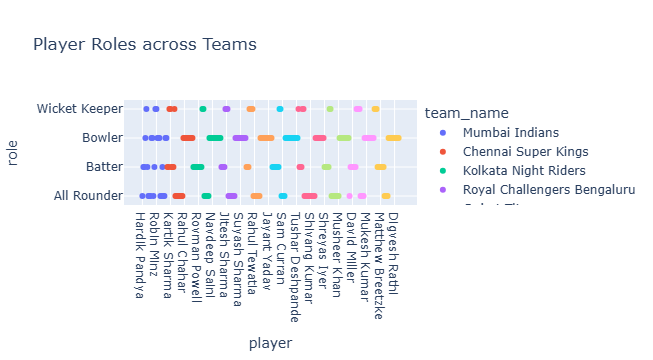

In [40]:
#  Scatter: Player vs Role (colored by Team)
fig = px.scatter(df, x="player", y="role", color="team_name",
                 title="Player Roles across Teams")
fig.show()


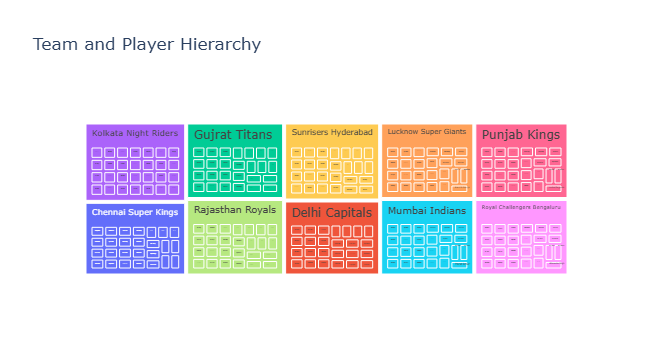

In [41]:
# 2 Treemap: Team → Player
fig = px.treemap(df, path=["team_name","player"], color="team_name",
                 title="Team and Player Hierarchy")
fig.show()

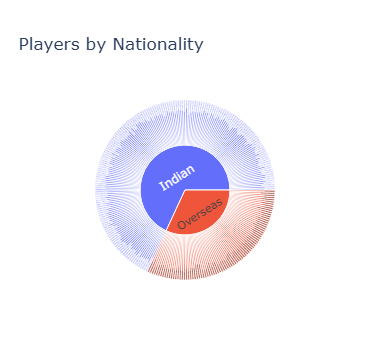

In [42]:
#  Sunburst: Nationality → Player
fig = px.sunburst(df, path=["nationality","player"], color="nationality",
                  title="Players by Nationality")
fig.show()


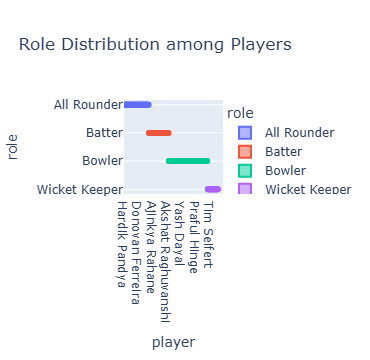

In [43]:
#  Violin: Role Distribution by Player
fig = px.violin(df, x="player", y="role", color="role",
                box=True, points="all",
                title="Role Distribution among Players")
fig.show()


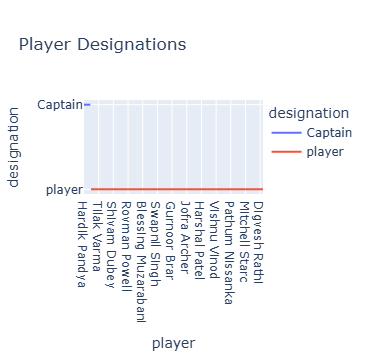

In [44]:

#  Line: Player vs Designation
fig = px.line(df, x="player", y="designation", color="designation",
              title="Player Designations")
fig.show()


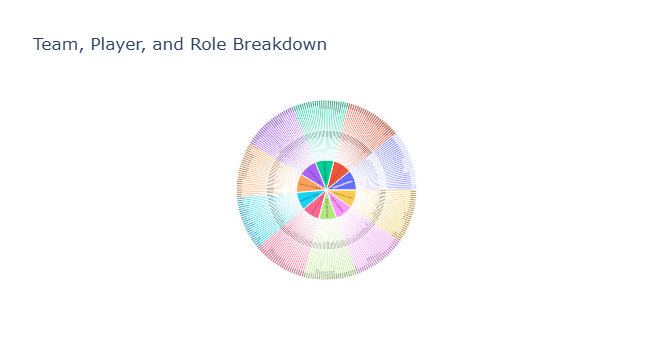

In [45]:
#  Sunburst: Team → Player → Role
fig = px.sunburst(df, path=["team_name","player","role"],
                  title="Team, Player, and Role Breakdown")
fig.show()


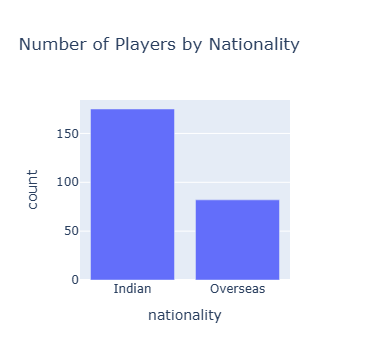

In [46]:
#  Bar: Nationality vs Count of Players
count_nat = df.groupby("nationality").size().reset_index(name="count")
fig = px.bar(count_nat, x="nationality", y="count",
             title="Number of Players by Nationality")
fig.show()


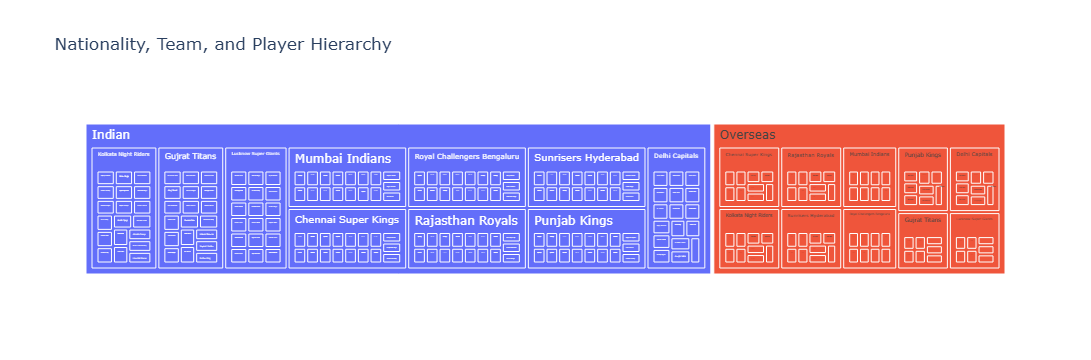

In [47]:
# Treemap: Nationality → Team → Player
fig = px.treemap(df, path=["nationality","team_name","player"], color="nationality",
                 title="Nationality, Team, and Player Hierarchy")
fig.show()

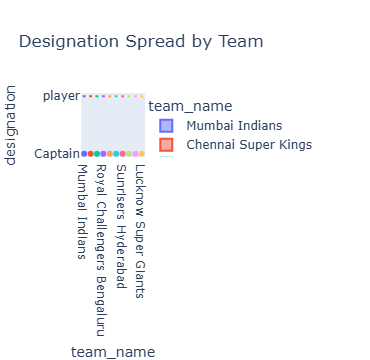

In [48]:
#  Box: Team vs Designation Spread
fig = px.box(df, x="team_name", y="designation", color="team_name",title="Designation Spread by Team")
fig.show()

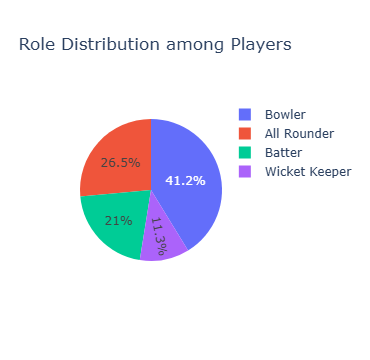

In [49]:

#  Pie: Role Distribution
count_role = df.groupby("role").size().reset_index(name="count")
fig = px.pie(count_role, names="role", values="count",title="Role Distribution among Players")
fig.show()

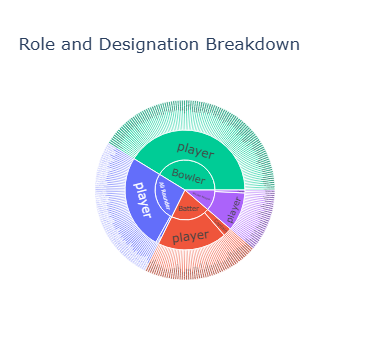

In [50]:

#  Sunburst: Role → Designation → Player
fig = px.sunburst(df, path=["role","designation","player"], color="role",title="Role and Designation Breakdown")
fig.show()
